### Introduction

Customer feedback plays a crucial role in helping airlines understand passenger satisfaction and identify areas for improvement. In this project, we analyze British Airways customer reviews using sentiment analysis techniques to classify opinions as positive or negative. By applying natural language processing (NLP) and machine learning methods, the goal is to uncover key patterns in customer sentiment and provide data-driven insights that can support service improvement and customer experience strategies.

In [2]:
## import libs
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

#!pip install nltk
#nltk.download('all')

In [4]:
data = pd.read_csv('BA_reviews.csv')

In [6]:
data

,Unnamed: 0,reviews
0,0,✅ Trip Verified | We are extremely grateful ...
1,1,✅ Trip Verified | I had an appalling experie...
2,2,"Not Verified | Good points, the cabin crew, t..."
3,3,"Not Verified | It was a decent flight, reason..."
4,4,✅ Trip Verified | I really like flying Briti...
...,...,...
2995,2995,Great flight with BA - departure at Milan was ...
2996,2996,My wife and I flew from Toronto to London (ret...
2997,2997,I didn't really know what to expect from this ...
2998,2998,Given BA's bizarre and relentless assault on i...


In [8]:
data.shape

(3000, 2)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  3000 non-null   int64 
 1   reviews     3000 non-null   object
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [12]:
data = data.drop('Unnamed: 0',axis = 1)

In [14]:
data.head()

,reviews
0,✅ Trip Verified | We are extremely grateful ...
1,✅ Trip Verified | I had an appalling experie...
2,"Not Verified | Good points, the cabin crew, t..."
3,"Not Verified | It was a decent flight, reason..."
4,✅ Trip Verified | I really like flying Briti...


In [16]:
## Test Preprosessing and Tokenization

In [18]:
import re

In [20]:
# initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Define preprocessing function
def preprocess_text(text):
    # converting text to low
    text = text.lower()
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [token for token in tokens if token.isalpha()]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = [token for token in tokens if token not in stopwords.words('english')]
    return ' '.join(tokens)
    
    
    # nltk.download('wordnet')


In [22]:
data['reviews'] = data['reviews'].apply(preprocess_text)

In [23]:
data

,reviews
0,trip verified extremely grateful crew flight c...
1,trip verified appalling experience british air...
2,verified good point cabin crew helpful profess...
3,verified wa decent flight reasonable comfortab...
4,trip verified really like flying british airwa...
...,...
2995,great flight ba departure milan wa great despi...
2996,wife flew toronto london return using ba busin...
2997,didnt really know expect flight couple year si...
2998,given ba bizarre relentless assault premium pa...


In [26]:
# Define a list of aviation words to remove
aviation_words = [
    'aircraft', 'airport', 'pilot', 'flight', 'aviation', 'airline','verified' 
    'crew', 'passenger', 'cargo', 'plane', 'jet', 'turbine', 'engine', 
    'wing', 'tail', 'cockpit', 'control', 'tower', 'runway', 'taxi', 
    'takeoff', 'landing', 'gate', 'terminal', 'baggage', 'checkin', 
    'security', 'boarding', 'departure', 'arrival', 'delay', 'cancellation',
    'helicopter', 'glider', 'airshow', 'aerobatics', 'flying', 'pilot', 
    'copilot', 'navigator', 'airtraffic', 'controller', 'dispatch', 'ramp', 
    'ground', 'handling', 'fuel', 'maintenance', 'repair', 'overhaul','wa','ba','trip','given'
]

# Remove aviation words from the text data
data['reviews'] = data['reviews'].apply(lambda x: ' '.join([word for word in x.split() if word.lower() not in aviation_words]))


In [28]:
data

,reviews
0,verified extremely grateful crew cape town hea...
1,verified appalling experience british airway s...
2,verified good point cabin crew helpful profess...
3,verified decent reasonable comfortable seat ke...
4,verified really like british airway particular...
...,...
2995,great milan great despite small relatively emp...
2996,wife flew toronto london return using business...
2997,didnt really know expect couple year since las...
2998,bizarre relentless assault premium dropped bac...


### Sentiment Analysis

In [31]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
#nltk.download('vader_lexicon')

In [33]:
# Initialize the VADER sentiment analysis tool
sia = SentimentIntensityAnalyzer()

In [35]:
# Perform sentiment analysis on the text data
data['sentiment'] = data['reviews'].apply(lambda x: sia.polarity_scores(x)['compound'])


In [36]:
data.head()

,reviews,sentiment
0,verified extremely grateful crew cape town hea...,0.8016
1,verified appalling experience british airway s...,-0.9777
2,verified good point cabin crew helpful profess...,0.9413
3,verified decent reasonable comfortable seat ke...,0.9300
4,verified really like british airway particular...,0.9701


In [39]:
# Define a function to categorize sentiment
def categorize_sentiment(sentiment):
    if sentiment >= 0.05:
        return 'Positive'
    elif sentiment <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'


In [41]:
# Categorize sentiment
data['sentiment_category'] = data['sentiment'].apply(categorize_sentiment)


In [43]:
data.head(10)

,reviews,sentiment,sentiment_category
0,verified extremely grateful crew cape town hea...,0.8016,Positive
1,verified appalling experience british airway s...,-0.9777,Negative
2,verified good point cabin crew helpful profess...,0.9413,Positive
3,verified decent reasonable comfortable seat ke...,0.9300,Positive
4,verified really like british airway particular...,0.9701,Positive
5,verified could book online night system arrive...,-0.4767,Negative
6,verified rough experience recent year look for...,0.9344,Positive
7,verified comfortable best excellent start chel...,0.9939,Positive
8,verified punta cana b check straightforward se...,0.9797,Positive
9,verified employee venice rude u made mistake g...,-0.8020,Negative


In [45]:
# Count the number of positive, negative, and neutral sentiments
sentiment_counts = data['sentiment_category'].value_counts()
sentiment_counts

sentiment_category
Positive    1884
Negative    1061
Neutral       55
Name: count, dtype: int64

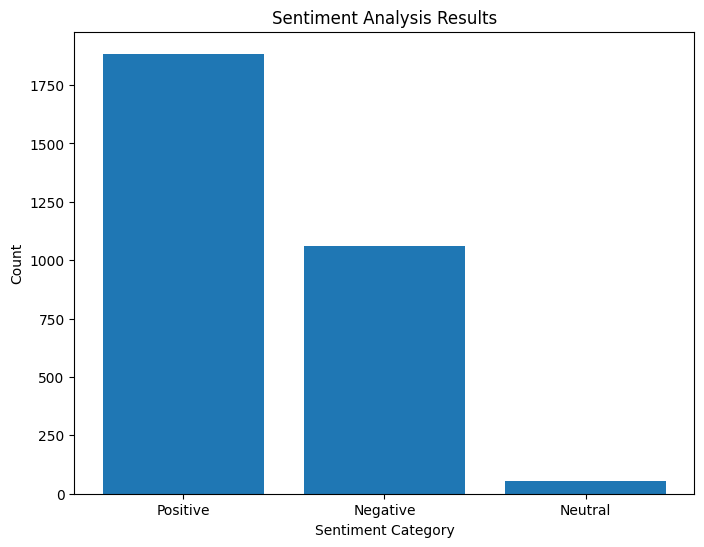

In [47]:
# Create a bar chart
plt.figure(figsize=(8, 6))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.title('Sentiment Analysis Results')
plt.show()



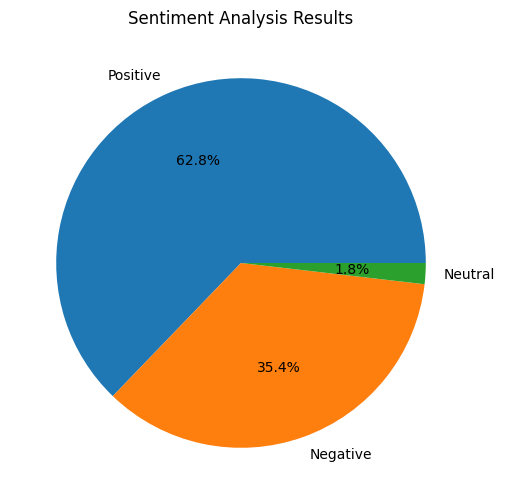

In [49]:
# Create a pie chart
plt.figure(figsize=(8, 6))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title('Sentiment Analysis Results')
plt.show()

## Building a Predictive Model

In [52]:
import warnings
warnings.filterwarnings('ignore')

In [54]:
data.head()

,reviews,sentiment,sentiment_category
0,verified extremely grateful crew cape town hea...,0.8016,Positive
1,verified appalling experience british airway s...,-0.9777,Negative
2,verified good point cabin crew helpful profess...,0.9413,Positive
3,verified decent reasonable comfortable seat ke...,0.9300,Positive
4,verified really like british airway particular...,0.9701,Positive


In [56]:
X = data['reviews'] # our feature or input
y = data['sentiment_category'] # our target or output

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words = 'english')
tfidf.fit(X_train)

TfidfVectorizer(stop_words='english')

In [62]:
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [64]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train_tfidf,y_train)

MultinomialNB()

In [66]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter = 1000)
log_model.fit(X_train_tfidf,y_train)

LogisticRegression(max_iter=1000)

In [68]:
from sklearn.svm import SVC, LinearSVC
rbf_svc = SVC()
rbf_svc.fit(X_train_tfidf,y_train)

SVC()

In [70]:
linear_svc = LinearSVC()
linear_svc.fit(X_train_tfidf,y_train)

LinearSVC()

In [72]:
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay,accuracy_score

In [74]:
def report(model):
    preds = model.predict(X_test_tfidf)
    print(classification_report(y_test,preds))
    ConfusionMatrixDisplay.from_estimator(model,X_test_tfidf,y_test,cmap='plasma')

              precision    recall  f1-score   support

    Negative       0.83      0.21      0.34       318
     Neutral       0.00      0.00      0.00        20
    Positive       0.67      0.98      0.80       562

    accuracy                           0.68       900
   macro avg       0.50      0.40      0.38       900
weighted avg       0.71      0.68      0.62       900



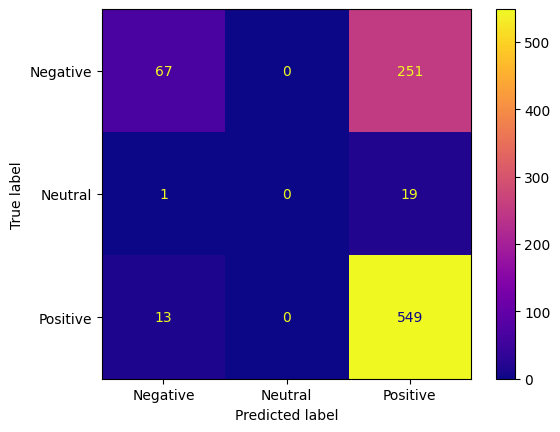

In [76]:
report(nb)

              precision    recall  f1-score   support

    Negative       0.74      0.66      0.70       318
     Neutral       0.00      0.00      0.00        20
    Positive       0.81      0.88      0.84       562

    accuracy                           0.79       900
   macro avg       0.52      0.52      0.51       900
weighted avg       0.77      0.79      0.77       900



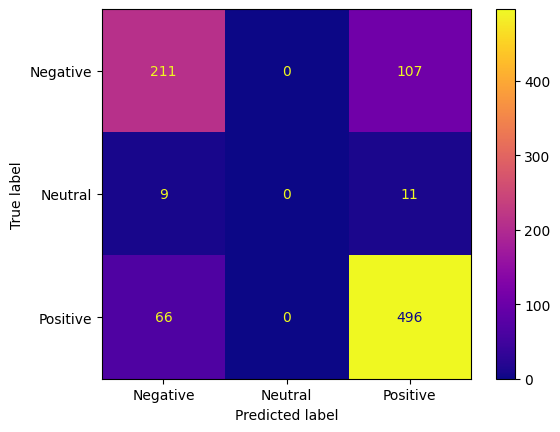

In [78]:
report(log_model)

              precision    recall  f1-score   support

    Negative       0.72      0.61      0.66       318
     Neutral       0.00      0.00      0.00        20
    Positive       0.79      0.88      0.83       562

    accuracy                           0.77       900
   macro avg       0.50      0.50      0.50       900
weighted avg       0.75      0.77      0.75       900



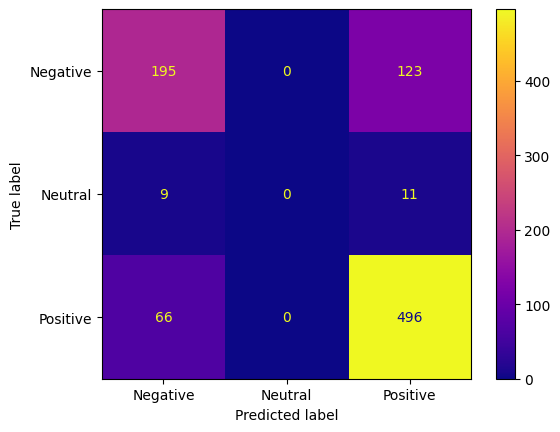

In [80]:
report(rbf_svc)

              precision    recall  f1-score   support

    Negative       0.73      0.70      0.72       318
     Neutral       0.00      0.00      0.00        20
    Positive       0.82      0.87      0.85       562

    accuracy                           0.79       900
   macro avg       0.52      0.52      0.52       900
weighted avg       0.77      0.79      0.78       900



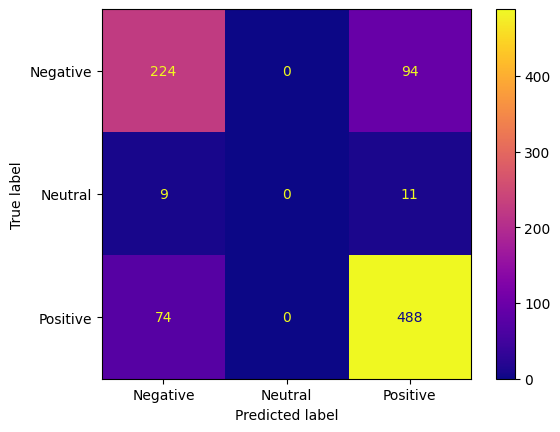

In [82]:
report(linear_svc)

In [84]:
# creating pipe line
from sklearn.pipeline import Pipeline

In [86]:
pipe = Pipeline([('tfidf',TfidfVectorizer()),
                ('svc',LinearSVC())])

In [88]:
pipe.fit(X,y)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('svc', LinearSVC())])

In [90]:
pipe.predict(["good"])

array(['Positive'], dtype=object)

# Deployemnt

In [93]:
import joblib

# save pipeline model
joblib.dump(pipe, "sentiment_model.pkl")

print("Model saved as sentiment_model.pkl ")


Model saved as sentiment_model.pkl 


In [95]:
import pickle
pickle.dump(pipe, open("sentiment_model.pkl", "wb"))
